# Explore Fish Counts

Loads `data/2025-11-19_discount_f_g.json` (true count **f**, detector count **g**, and **clip** id with date) and produces exploratory plots.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## Load data

In [3]:
with open("../data/maria_frame_counts.json") as fp:
    raw = json.load(fp)

df = pd.DataFrame({
    "true": np.array(raw["f"], dtype=np.int32),
    "detector": np.array(raw["g"], dtype=np.float64)
})

print(f"Loaded {len(df)} observations")
print(f"True count:    min={df['true'].min()}, max={df['true'].max()}, mean={df['true'].mean():.2f}")
print(f"Detector:     min={df['detector'].min()}, max={df['detector'].max()}, mean={df['detector'].mean():.2f}")
print(f"Dates: {df['date'].nunique()} unique ({df['date'].min()} to {df['date'].max()})")
df.head(10)

Loaded 1763 observations
True count:    min=0, max=4, mean=1.14
Detector:     min=0.0, max=4.0, mean=0.72


KeyError: 'date'

## 1. Heatmap: detector count (x) vs true count (y), columns normalized

For each detector count (column), the distribution of true counts is normalized so columns sum to 1.

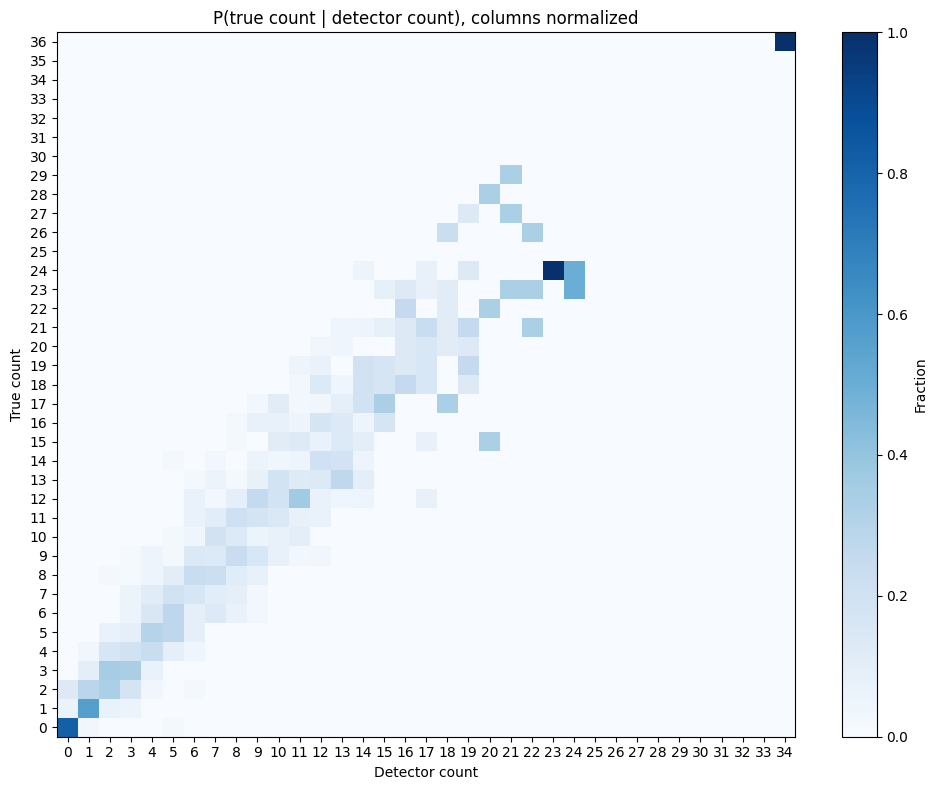

In [3]:
ct = pd.crosstab(df["true"], df["detector_bin"], normalize="columns")
# Align so all detector values in range appear
g_min, g_max = int(df["detector"].min()), int(df["detector"].max())
cols = np.arange(g_min, g_max + 1)
ct = ct.reindex(columns=cols).fillna(0)
ct = ct.reindex(index=np.arange(0, df["true"].max() + 1)).fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(ct.values, aspect="auto", origin="lower", cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(ct.columns)))
ax.set_xticklabels(ct.columns.astype(int))
ax.set_yticks(np.arange(ct.index.size))
ax.set_yticklabels(ct.index.astype(int))
ax.set_xlabel("Detector count")
ax.set_ylabel("True count")
ax.set_title("P(true count | detector count), columns normalized")
plt.colorbar(im, ax=ax, label="Fraction")
plt.tight_layout()
plt.show()

## 2. Variance of true counts vs detector count (with y=x line)

For each detector count value, compute the variance of the corresponding true counts; then plot variance vs detector count. The y=x line is the Poisson expectation (variance = mean).

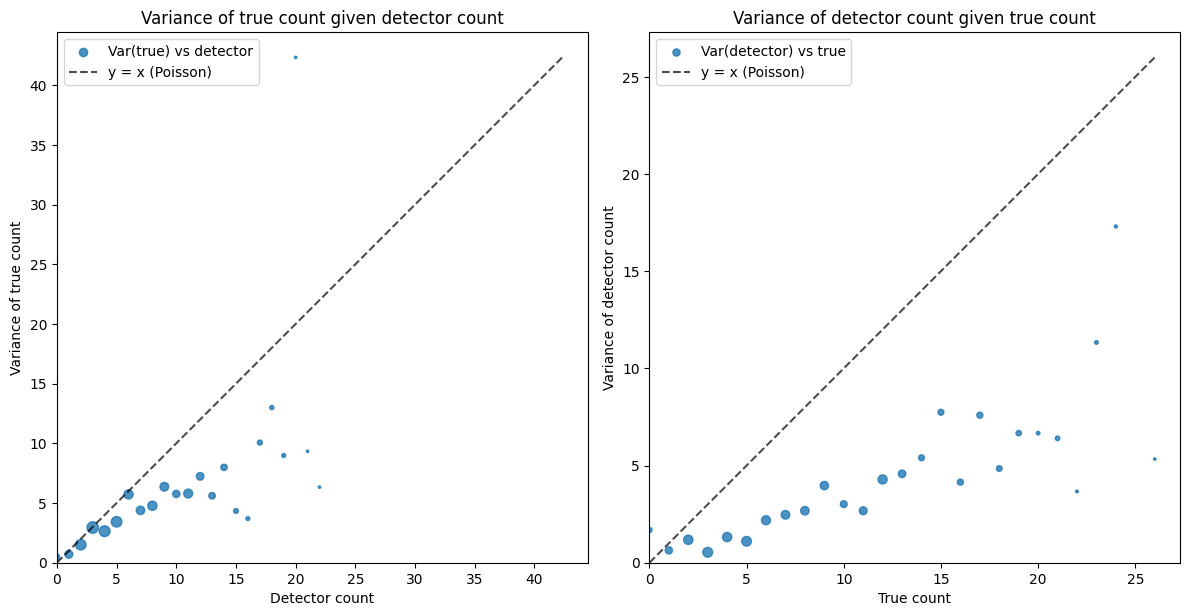

In [4]:
by_g = df.groupby("detector_bin")["true"].agg(["mean", "var", "count"]).reset_index()
by_g = by_g[by_g["count"] >= 3]
by_t = df.groupby("true")["detector"].agg(["mean", "var", "count"]).reset_index()
by_t = by_t[by_t["count"] >= 3]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False, sharey=False)

# Left: Variance of true vs detector count
ax = axes[0]
ax.scatter(by_g["detector_bin"], by_g["var"], s=by_g["count"].clip(1, 80), alpha=0.8, label="Var(true) vs detector")
lim = max(by_g["detector_bin"].max(), by_g["var"].max(), 1)
ax.plot([0, lim], [0, lim], "k--", alpha=0.7, label="y = x (Poisson)")
ax.set_xlabel("Detector count")
ax.set_ylabel("Variance of true count")
ax.set_title("Variance of true count given detector count")
ax.legend()
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.set_aspect("equal")

# Right: Variance of detector vs true count
ax = axes[1]
ax.scatter(by_t["true"], by_t["var"], s=by_t["count"].clip(1, 80), alpha=0.8, label="Var(detector) vs true")
lim = max(by_t["true"].max(), by_t["var"].max(), 1)
ax.plot([0, lim], [0, lim], "k--", alpha=0.7, label="y = x (Poisson)")
ax.set_xlabel("True count")
ax.set_ylabel("Variance of detector count")
ax.set_title("Variance of detector count given true count")
ax.legend()
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

(Variance plot uses `detector_bin` from rounded detector count; points sized by sample count.)

## 3. Other informative plots

Marginal distributions, scatter of true vs detector, and mean true vs detector.

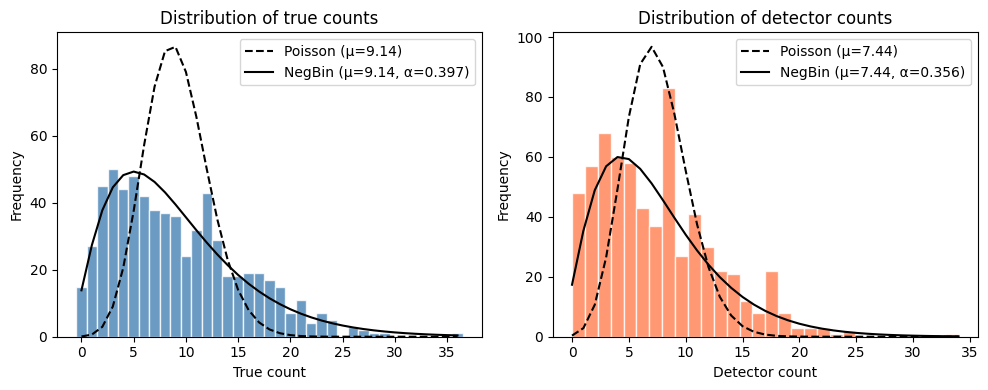

In [5]:
from scipy.stats import poisson, nbinom
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---------------------------
# TRUE COUNTS: histogram + Poisson + NegBin
# ---------------------------
true = df["true"].to_numpy()
x_true = np.arange(0, true.max() + 1)

axes[0].hist(
    true,
    bins=np.arange(-0.5, true.max() + 1.5),
    alpha=0.8,
    color="steelblue",
    edgecolor="white",
)
axes[0].set_xlabel("True count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of true counts")

# Poisson fit (MLE mean)
mu_pois_true = true.mean()
pmf_pois_true = poisson.pmf(x_true, mu_pois_true) * len(true)
axes[0].plot(x_true, pmf_pois_true, "k--", label=f"Poisson (μ={mu_pois_true:.2f})")

# Negative Binomial fit via statsmodels NB2 (Var = mu + alpha * mu^2)
X = np.ones((len(true), 1))  # intercept only, 2D design matrix
nb_model = sm.NegativeBinomial(true, X)
nb_fit = nb_model.fit(disp=False)

mu_nb_true = float(np.exp(nb_fit.params[0]))   # mean
alpha_nb_true = float(nb_fit.params[-1])      # overdispersion
n = 1.0 / alpha_nb_true                        # scipy 'n' (size)
p = n / (n + mu_nb_true)                       # scipy 'p' (success prob)

pmf_nb_true = nbinom.pmf(x_true, n, p) * len(true)
axes[0].plot(
    x_true,
    pmf_nb_true,
    "k-",
    label=f"NegBin (μ={mu_nb_true:.2f}, α={alpha_nb_true:.3f})",
)

axes[0].legend()

# ---------------------------
# DETECTOR COUNTS: histogram + Poisson (as you had it)
# ---------------------------
det = df["detector"].to_numpy()
x_det = np.arange(0, det.max() + 1)

axes[1].hist(det, bins=30, alpha=0.8, color="coral", edgecolor="white")
axes[1].set_xlabel("Detector count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of detector counts")

mu_pois_det = det.mean()
pmf_pois_det = poisson.pmf(x_det, mu_pois_det) * len(det)
axes[1].plot(x_det, pmf_pois_det, "k--", label=f"Poisson (μ={mu_pois_det:.2f})")
axes[1].legend()

# negative binomial fit
# Negative Binomial fit via statsmodels NB2 (Var = mu + alpha * mu^2)
det = df["detector"].to_numpy()
x_det = np.arange(0, det.max() + 1)
X = np.ones((len(det), 1))  # intercept only, 2D design matrix
nb_model = sm.NegativeBinomial(det, X)
nb_fit = nb_model.fit(disp=False)

mu_nb_det = float(np.exp(nb_fit.params[0]))   # mean
alpha_nb_det = float(nb_fit.params[-1])      # overdispersion
n = 1.0 / alpha_nb_det                        # scipy 'n' (size)
p = n / (n + mu_nb_det)                       # scipy 'p' (success prob)

pmf_nb_det = nbinom.pmf(x_det, n, p) * len(det)
axes[1].plot(
    x_det,
    pmf_nb_det,
    "k-",
    label=f"NegBin (μ={mu_nb_det:.2f}, α={alpha_nb_det:.3f})",
)

axes[1].legend()

plt.tight_layout()
plt.show()


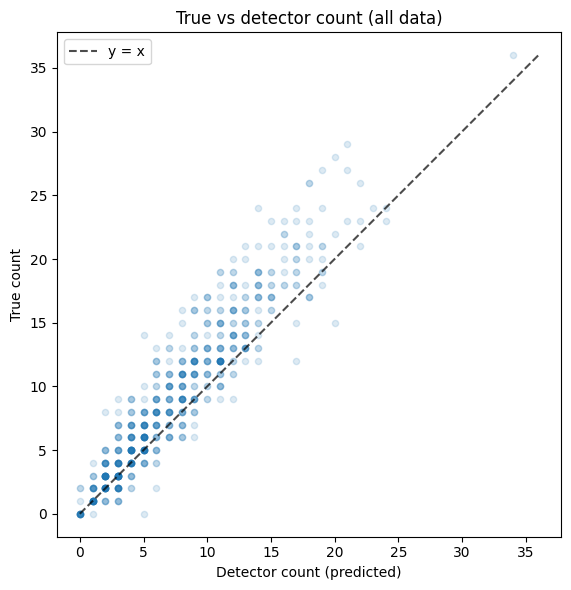

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["detector"], df["true"], alpha=0.15, s=20)
ax.plot([0, df[["true", "detector"]].max().max()], [0, df[["true", "detector"]].max().max()], "k--", alpha=0.7, label="y = x")
ax.set_xlabel("Detector count (predicted)")
ax.set_ylabel("True count")
ax.set_title("True vs detector count (all data)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

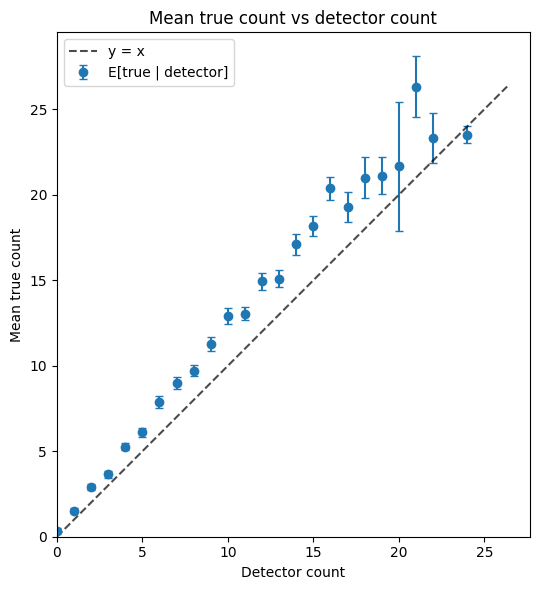

In [7]:
by_g = df.groupby("detector_bin")["true"].agg(["mean", "std", "count"]).reset_index()
by_g = by_g[by_g["count"] >= 2]

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    by_g["detector_bin"], by_g["mean"], yerr=by_g["std"] / np.sqrt(by_g["count"]),
    fmt="o", capsize=3, label="E[true | detector]"
)
lim = max(by_g["detector_bin"].max(), by_g["mean"].max(), 1)
ax.plot([0, lim], [0, lim], "k--", alpha=0.7, label="y = x")
ax.set_xlabel("Detector count")
ax.set_ylabel("Mean true count")
ax.set_title("Mean true count vs detector count")
ax.legend()
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. True (y) vs predicted/detector (x) by date

One subplot per date; points with alpha=0.1 to show density.

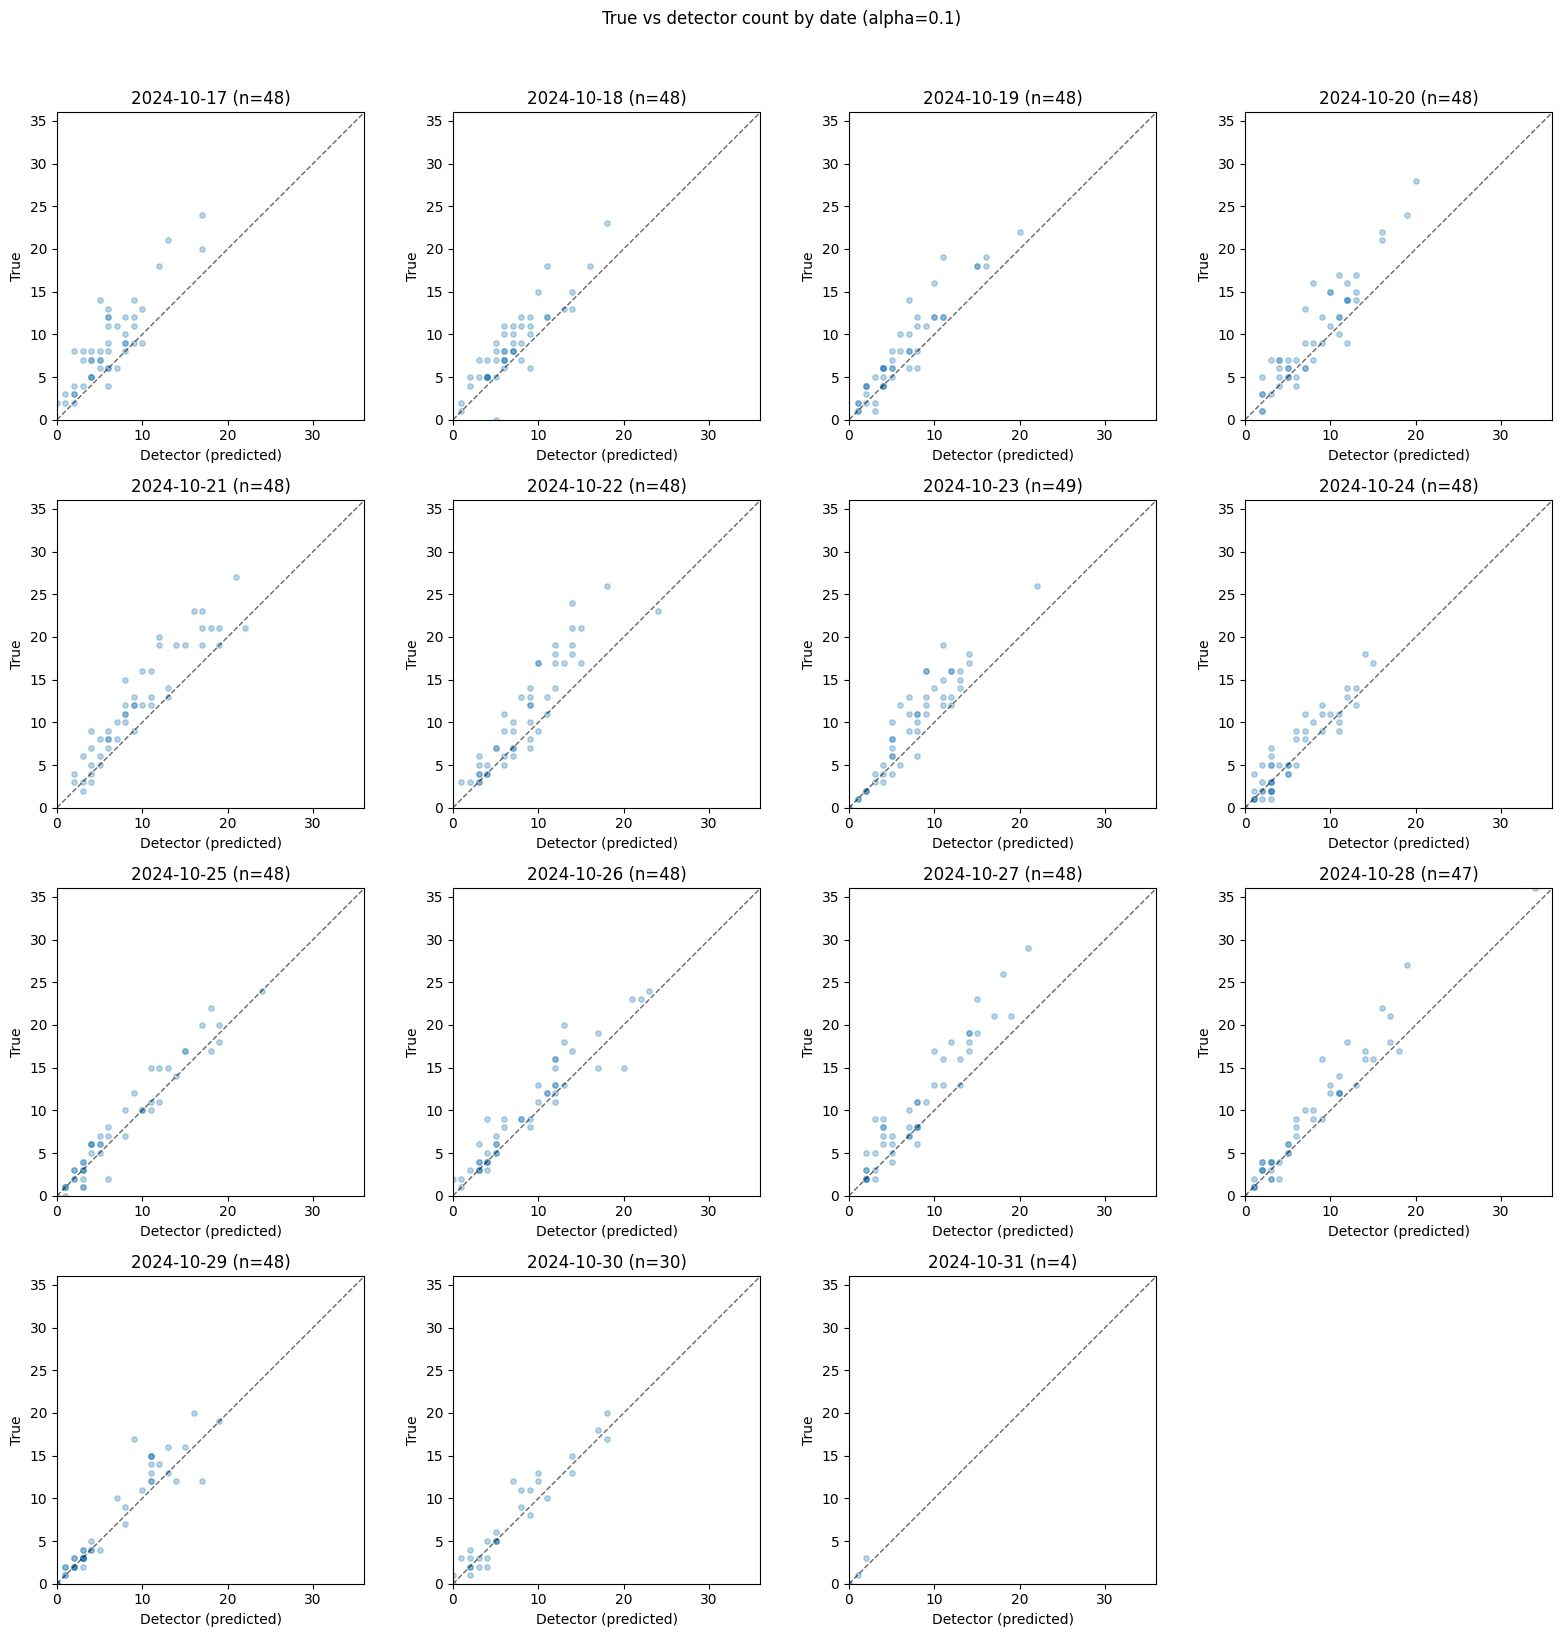

In [8]:
dates = sorted(df["date"].unique())
n_dates = len(dates)
n_cols = 4
n_rows = int(np.ceil(n_dates / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)
lim = max(df["true"].max(), df["detector"].max())

for i, date in enumerate(dates):
    r, c = i // n_cols, i % n_cols
    ax = axes[r, c]
    sub = df[df["date"] == date]
    n_points = len(sub)
    ax.scatter(sub["detector"], sub["true"], alpha=0.3, s=15)
    ax.plot([0, lim], [0, lim], "k--", alpha=0.6, lw=1)
    ax.set_xlabel("Detector (predicted)")
    ax.set_ylabel("True")
    ax.set_title(f"{date} (n={n_points})")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")

for j in range(i + 1, axes.size):
    r, c = j // n_cols, j % n_cols
    axes[r, c].set_visible(False)

plt.suptitle("True vs detector count by date (alpha=0.1)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Distribution of fish counts by hour of day

Day is split into 12 two-hour windows (0–2AM, 2–4AM, …, 22–24). Each subplot shows the distribution of true counts in that window.

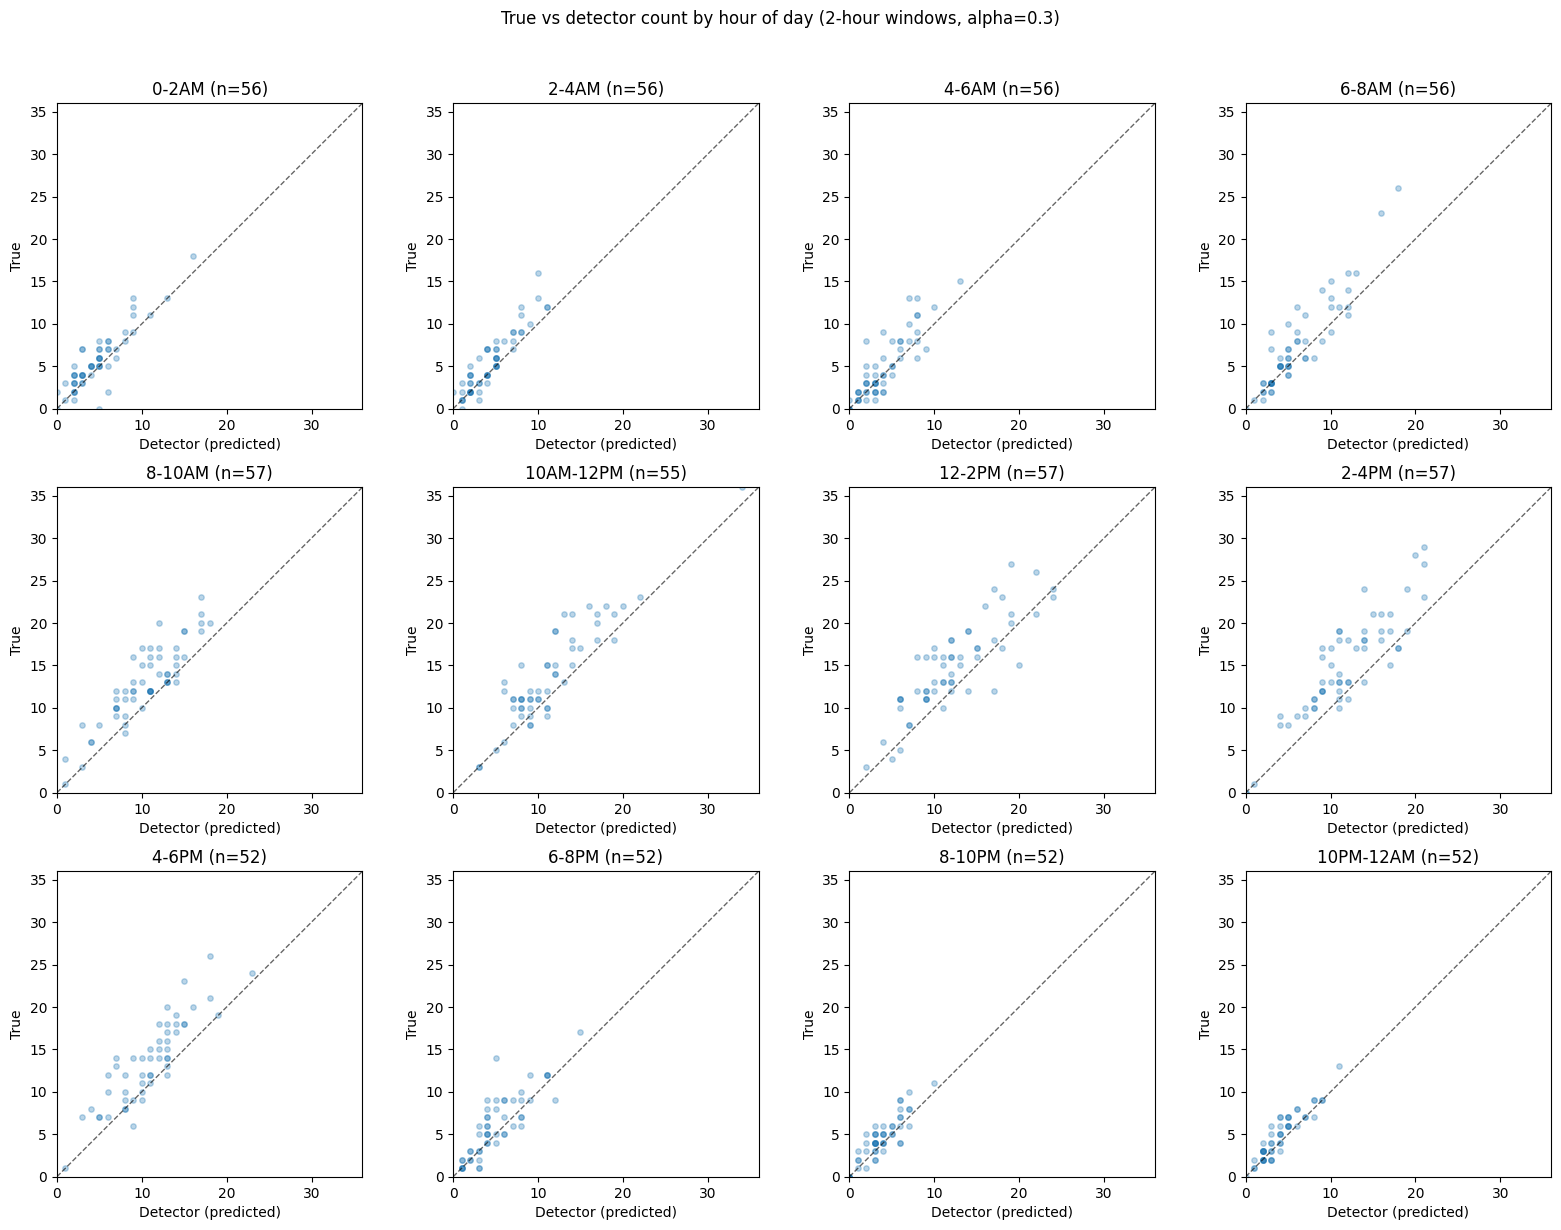

In [10]:
videos = sorted(df["video_id"].unique())
n_videos = len(videos)
n_cols = 4
n_rows = int(np.ceil(n_videos / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)
lim = max(df["true"].max(), df["detector"].max())

for i, video in enumerate(videos):
    r, c = i // n_cols, i % n_cols
    ax = axes[r, c]
    sub = df[df["video_id"] == video]
    n_points = len(sub)
    ax.scatter(sub["detector"], sub["true"], alpha=0.3, s=15)
    ax.plot([0, lim], [0, lim], "k--", alpha=0.6, lw=1)
    ax.set_xlabel("Detector (predicted)")
    ax.set_ylabel("True")
    ax.set_title(f"{video} (n={n_points})")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")

# Hide unused subplots
for j in range(i + 1, axes.size):
    r, c = j // n_cols, j % n_cols
    axes[r, c].set_visible(False)

plt.suptitle("True vs detector count by video (alpha=0.3)", y=1.02)
plt.tight_layout()
plt.show()